In [1]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/raw/creditcard.csv"

df = pd.read_csv(DATA_PATH)

df = (
    df
    .drop_duplicates()
    .sort_values("Time")
    .reset_index(drop=True)
)

print(df.shape)
print(df["Class"].value_counts())

(283726, 31)
Class
0    283253
1       473
Name: count, dtype: int64


In [2]:
n = len(df)

train_end = int(n * 0.60)
val_end = int(n * 0.80)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

In [3]:
for name, part in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:
    print(
        name,
        len(part),
        part["Class"].sum(),
        f"{part['Class'].mean():.4%}"
    )

Train 170235 342 0.2009%
Validation 56745 57 0.1004%
Test 56746 74 0.1304%


In [4]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:

    result = df.copy()

    # Amount has a very skewed distribution.
    result["LogAmount"] = np.log1p(
        result["Amount"].clip(lower=0)
    )

    # Easier scale/interpretation than seconds.
    result["TimeHours"] = (
        result["Time"] / 3600.0
    )

    # Raw Time is now redundant.
    result = result.drop(
        columns=["Time"]
    )

    return result

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_PATH = "../data/raw/creditcard.csv"

df_ml = pd.read_csv(DATA_PATH)

df_ml = df_ml.drop_duplicates()

X = df_ml.drop(columns=["Class"])
y = df_ml["Class"]

In [12]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    stratify=y_train_val,
    random_state=42
)

In [13]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (170235, 30)
Validation: (56745, 30)
Test: (56746, 30)


In [14]:
X_train_fe = build_features(X_train)
X_val_fe = build_features(X_val)
X_test_fe = build_features(X_test)

In [15]:
print("Before:", X_train.shape)
print("After:", X_train_fe.shape)

X_train_fe.head()

Before: (170235, 30)
After: (170235, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,LogAmount,TimeHours
103118,-1.466684,0.437843,1.798819,-1.955137,-1.436692,0.141052,-1.339819,1.163623,-1.273979,-0.360421,...,1.189609,-0.368531,-0.323312,0.410506,-0.108637,-0.307629,-0.095969,8.99,2.301585,19.028889
268849,2.099619,-0.023369,-1.369803,0.224338,0.339848,-0.669249,0.224435,-0.315935,0.446580,0.035825,...,-0.739342,0.237677,-0.748881,-0.181017,0.244591,-0.063086,-0.065425,5.99,1.944481,45.391667
2199,-1.960524,1.438062,-0.067457,-0.382996,0.369982,-0.113959,0.181212,0.504365,0.062941,0.624255,...,-0.847225,0.241987,-1.030383,0.234938,0.156216,0.338689,0.100345,16.00,2.833213,0.477500
177231,1.838230,-0.641136,-0.425984,0.560873,-0.835237,0.005472,-1.102837,0.245831,1.666006,-0.544545,...,0.399034,0.188064,0.483990,-0.557038,0.485454,0.003685,0.010003,75.34,4.335197,34.192500
227283,0.751899,-2.034001,-1.388385,1.703266,-0.369474,0.535422,0.645324,-0.170321,0.656970,-0.257649,...,-1.277865,-0.182382,0.156963,-0.475163,-1.138433,-0.064637,0.087829,648.84,6.476726,40.281944


In [16]:
scale_columns = [
    "Amount",
    "LogAmount",
    "TimeHours"
]

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(
    transformers=[
        (
            "scale",
            StandardScaler(),
            scale_columns
        )
    ],
    remainder="passthrough"
)

In [18]:
logistic_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

In [19]:
logistic_model.fit(
    X_train_fe,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['V1','V2','V3',...,'Amount','LogAmount','TimeHours']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwer

In [20]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

random_forest_model.fit(
    X_train_fe,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced_subsample'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consid

In [21]:
negative_count = (
    y_train == 0
).sum()

positive_count = (
    y_train == 1
).sum()

scale_pos_weight = (
    negative_count /
    positive_count
)

print(
    "Negative:",
    negative_count
)

print(
    "Positive:",
    positive_count
)

print(
    "scale_pos_weight:",
    scale_pos_weight
)

Negative: 169951
Positive: 284
scale_pos_weight: 598.419014084507


In [22]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",
    eval_metric="aucpr",

    random_state=42,
    n_jobs=-1
)

In [23]:
xgb_model.fit(
    X_train_fe,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [24]:
xgb_val_probability = (
    xgb_model
    .predict_proba(X_val_fe)[:, 1]
)

In [25]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,

    num_leaves=31,

    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

In [26]:
lgbm_model.fit(
    X_train_fe,
    y_train
)

,learning_rate,0.05
,n_estimators,400
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,scale_pos_weight,np.float64(598.419014084507)
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1


In [27]:
lgbm_val_probability = (
    lgbm_model
    .predict_proba(X_val_fe)[:, 1]
)

In [28]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.05,

    class_weights=[
        1.0,
        scale_pos_weight
    ],

    loss_function="Logloss",

    random_seed=42,
    verbose=False
)

In [29]:
catboost_model.fit(
    X_train_fe,
    y_train
)

CatBoostClassifier(class_weights=[1.0, np.float64(598.419014084507)], depth=6, iterations=400, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=False)

In [30]:
catboost_val_probability = (
    catboost_model
    .predict_proba(X_val_fe)[:, 1]
)

In [31]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    auc
)


def evaluate_model(
    y_true,
    probabilities,
    threshold=0.5
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_true,
            probabilities
        )
    )

    return {
        "threshold": threshold,

        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_true,
            probabilities
        ),

        "average_precision":
            average_precision_score(
                y_true,
                probabilities
            ),

        "pr_auc": auc(
            recall_curve,
            precision_curve
        ),

        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

In [32]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": catboost_model,
}

In [33]:
validation_results = []
validation_probabilities = {}

for name, model in models.items():

    probabilities = model.predict_proba(
        X_val_fe
    )[:, 1]

    validation_probabilities[name] = probabilities

    metrics = evaluate_model(
        y_val,
        probabilities,
        threshold=0.5
    )

    validation_results.append(
        {
            "model": name,
            **metrics
        }
    )

In [34]:
comparison_df = pd.DataFrame(
    validation_results
)

comparison_df.sort_values(
    "average_precision",
    ascending=False
)

,model,threshold,precision,recall,f1,roc_auc,average_precision,pr_auc,tn,fp,fn,tp
2,XGBoost,0.5,0.870968,0.861702,0.866310,0.978267,0.884669,0.884582,56639,12,13,81
1,Random Forest,0.5,0.918605,0.840426,0.877778,0.954609,0.878843,0.879601,56644,7,15,79
4,CatBoost,0.5,0.801980,0.861702,0.830769,0.968300,0.869432,0.869314,56631,20,13,81
0,Logistic Regression,0.5,0.054106,0.904255,0.102102,0.979042,0.785419,0.809024,55165,1486,9,85
3,LightGBM,0.5,0.040262,0.914894,0.077130,0.939337,0.036977,0.477631,54601,2050,8,86


## Model Evaluation Strategy

Because fraud represents a very small proportion of transactions,
accuracy is not used as the main evaluation metric.

The primary ranking metrics are:

- Average Precision
- PR-AUC

Additional operational metrics are:

- Recall
- Precision
- False Positives
- False Negatives

Final model selection also considers the hypothetical business cost
of false-negative and false-positive predictions.

In [35]:
FALSE_NEGATIVE_COST = 100_000
FALSE_POSITIVE_COST = 2_000

In [36]:
def find_best_threshold(
    y_true,
    probabilities,
    false_negative_cost,
    false_positive_cost
):
    thresholds = np.arange(
        0.001,
        1.000,
        0.001
    )

    rows = []

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            predictions,
            labels=[0, 1]
        ).ravel()

        business_cost = (
            fn * false_negative_cost
            +
            fp * false_positive_cost
        )

        rows.append(
            {
                "threshold": threshold,
                "business_cost": business_cost,
                "fp": fp,
                "fn": fn,
                "tp": tp,

                "precision":
                    precision_score(
                        y_true,
                        predictions,
                        zero_division=0
                    ),

                "recall":
                    recall_score(
                        y_true,
                        predictions,
                        zero_division=0
                    )
            }
        )

    result = pd.DataFrame(rows)

    best_row = result.loc[
        result[
            "business_cost"
        ].idxmin()
    ]

    return best_row, result

In [37]:
threshold_results = []

for name, probabilities in (
    validation_probabilities.items()
):

    best_row, _ = find_best_threshold(
        y_val,
        probabilities,
        FALSE_NEGATIVE_COST,
        FALSE_POSITIVE_COST
    )

    threshold_results.append(
        {
            "model": name,
            **best_row.to_dict()
        }
    )

In [38]:
threshold_comparison = (
    pd.DataFrame(
        threshold_results
    )
    .sort_values(
        "business_cost"
    )
)

threshold_comparison

,model,threshold,business_cost,fp,fn,tp,precision,recall
2,XGBoost,0.324,1040000.0,20.0,10.0,84.0,0.807692,0.893617
1,Random Forest,0.077,1062000.0,31.0,10.0,84.0,0.730435,0.893617
0,Logistic Regression,0.981,1248000.0,74.0,11.0,83.0,0.528662,0.882979
4,CatBoost,0.437,1248000.0,24.0,12.0,82.0,0.773585,0.872340
3,LightGBM,0.001,4900000.0,2050.0,8.0,86.0,0.040262,0.914894


In [39]:
comparison_df.sort_values(
    "average_precision",
    ascending=False
)

,model,threshold,precision,recall,f1,roc_auc,average_precision,pr_auc,tn,fp,fn,tp
2,XGBoost,0.5,0.870968,0.861702,0.866310,0.978267,0.884669,0.884582,56639,12,13,81
1,Random Forest,0.5,0.918605,0.840426,0.877778,0.954609,0.878843,0.879601,56644,7,15,79
4,CatBoost,0.5,0.801980,0.861702,0.830769,0.968300,0.869432,0.869314,56631,20,13,81
0,Logistic Regression,0.5,0.054106,0.904255,0.102102,0.979042,0.785419,0.809024,55165,1486,9,85
3,LightGBM,0.5,0.040262,0.914894,0.077130,0.939337,0.036977,0.477631,54601,2050,8,86


In [40]:
threshold_comparison.sort_values(
    "business_cost"
)

,model,threshold,business_cost,fp,fn,tp,precision,recall
2,XGBoost,0.324,1040000.0,20.0,10.0,84.0,0.807692,0.893617
1,Random Forest,0.077,1062000.0,31.0,10.0,84.0,0.730435,0.893617
0,Logistic Regression,0.981,1248000.0,74.0,11.0,83.0,0.528662,0.882979
4,CatBoost,0.437,1248000.0,24.0,12.0,82.0,0.773585,0.872340
3,LightGBM,0.001,4900000.0,2050.0,8.0,86.0,0.040262,0.914894


## Hyperparameter Tuning

Hyperparameter tuning is performed only for the strongest candidate
models identified on the validation set.

Average Precision is used as the main tuning metric because the fraud
class is highly imbalanced.

The test set remains untouched until final model selection.

In [41]:
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

from scipy.stats import (
    randint,
    uniform,
    loguniform
)

from xgboost import XGBClassifier

In [42]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = (
    negative_count / positive_count
)

print("Legitimate:", negative_count)
print("Fraud:", positive_count)
print(
    "scale_pos_weight:",
    round(scale_pos_weight, 2)
)

Legitimate: 169951
Fraud: 284
scale_pos_weight: 598.42


In [43]:
base_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=1
)

In [44]:
xgb_param_distributions = {

    "n_estimators":
        randint(200, 700),

    "max_depth":
        randint(3, 8),

    "learning_rate":
        loguniform(0.01, 0.20),

    "subsample":
        uniform(0.70, 0.30),

    "colsample_bytree":
        uniform(0.70, 0.30),

    "min_child_weight":
        randint(1, 10),

    "gamma":
        uniform(0.0, 2.0)
}

In [45]:
cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

In [46]:
xgb_search = RandomizedSearchCV(
    estimator=base_xgb,

    param_distributions=
        xgb_param_distributions,

    n_iter=20,

    scoring="average_precision",

    cv=cv,

    random_state=42,

    n_jobs=-1,

    verbose=2,

    refit=True
)

In [47]:
xgb_search.fit(
    X_train_fe,
    y_train
)

Fitting 4 folds for each of 20 candidates, totalling 80 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....001B88BF49310>, 'gamma': <scipy.stats....001B88BEBEC40>, 'learning_rate': <scipy.stats....001B88BF00AD0>, 'max_depth': <scipy.stats....001B88B82B390>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerat

In [48]:
print(
    "Best CV Average Precision:",
    xgb_search.best_score_
)

print(
    "\nBest parameters:"
)

xgb_search.best_params_

Best CV Average Precision: 0.844507805571763

Best parameters:


{'colsample_bytree': np.float64(0.8320457481218804),
 'gamma': np.float64(0.24407646968955765),
 'learning_rate': np.float64(0.04407984038169244),
 'max_depth': 5,
 'min_child_weight': 1,
 'n_estimators': 619,
 'subsample': np.float64(0.7546708263364187)}

In [49]:
best_xgb = (
    xgb_search.best_estimator_
)

In [50]:
best_xgb_val_probability = (
    best_xgb.predict_proba(
        X_val_fe
    )[:, 1]
)

In [51]:
best_xgb_val_results = (
    evaluate_model(
        y_val,
        best_xgb_val_probability,
        threshold=0.5
    )
)

best_xgb_val_results

{'threshold': 0.5,
 'precision': 0.9310344827586207,
 'recall': 0.8617021276595744,
 'f1': 0.8950276243093923,
 'roc_auc': 0.9726060684361922,
 'average_precision': 0.8845590904674184,
 'pr_auc': 0.8844795749035886,
 'tn': 56645,
 'fp': 6,
 'fn': 13,
 'tp': 81}

In [52]:
xgb_before_tuning = evaluate_model(
    y_val,
    xgb_val_probability,
    threshold=0.5
)

xgb_after_tuning = evaluate_model(
    y_val,
    best_xgb_val_probability,
    threshold=0.5
)

In [53]:
xgb_tuning_comparison = pd.DataFrame(
    [
        {
            "model":
                "XGBoost before tuning",
            **xgb_before_tuning
        },

        {
            "model":
                "XGBoost after tuning",
            **xgb_after_tuning
        }
    ]
)

xgb_tuning_comparison

,model,threshold,precision,recall,f1,roc_auc,average_precision,pr_auc,tn,fp,fn,tp
0,XGBoost before tuning,0.5,0.870968,0.861702,0.866310,0.978267,0.884669,0.884582,56639,12,13,81
1,XGBoost after tuning,0.5,0.931034,0.861702,0.895028,0.972606,0.884559,0.884480,56645,6,13,81


In [54]:
best_xgb_threshold_row, \
best_xgb_cost_df = (
    find_best_threshold(
        y_val,
        best_xgb_val_probability,
        FALSE_NEGATIVE_COST,
        FALSE_POSITIVE_COST
    )
)

In [55]:
best_xgb_threshold_row

threshold        1.400000e-02
business_cost    1.150000e+06
fp               7.500000e+01
fn               1.000000e+01
tp               8.400000e+01
precision        5.283019e-01
recall           8.936170e-01
Name: 13, dtype: float64

In [56]:
best_xgb_threshold = float(
    best_xgb_threshold_row[
        "threshold"
    ]
)

print(
    "Best XGBoost threshold:",
    best_xgb_threshold
)

Best XGBoost threshold: 0.014000000000000002


In [57]:
champion_candidates = (
    threshold_comparison.copy()
)

In [58]:
tuned_xgb_row = {
    "model":
        "XGBoost Tuned",

    **best_xgb_threshold_row.to_dict()
}

In [59]:
tuned_xgb_row = {
    "model":
        "XGBoost Tuned",

    **best_xgb_threshold_row.to_dict()
}

In [60]:
champion_candidates.sort_values(
    "business_cost"
)

,model,threshold,business_cost,fp,fn,tp,precision,recall
2,XGBoost,0.324,1040000.0,20.0,10.0,84.0,0.807692,0.893617
1,Random Forest,0.077,1062000.0,31.0,10.0,84.0,0.730435,0.893617
0,Logistic Regression,0.981,1248000.0,74.0,11.0,83.0,0.528662,0.882979
4,CatBoost,0.437,1248000.0,24.0,12.0,82.0,0.773585,0.872340
3,LightGBM,0.001,4900000.0,2050.0,8.0,86.0,0.040262,0.914894


In [61]:
from sklearn.metrics import (
    average_precision_score
)

tuned_xgb_ap = (
    average_precision_score(
        y_val,
        best_xgb_val_probability
    )
)

print(
    "Tuned XGBoost AP:",
    tuned_xgb_ap
)

Tuned XGBoost AP: 0.8845590904674184


In [62]:
champion_candidates["model"].tolist()

['XGBoost', 'Random Forest', 'Logistic Regression', 'CatBoost', 'LightGBM']

In [63]:
tuned_xgb_row = {
    "model": "XGBoost Tuned",
    **best_xgb_threshold_row.to_dict()
}

champion_candidates = pd.concat(
    [
        threshold_comparison,
        pd.DataFrame([tuned_xgb_row])
    ],
    ignore_index=True
)

champion_candidates.sort_values(
    "business_cost"
)

,model,threshold,business_cost,fp,fn,tp,precision,recall
0,XGBoost,0.324,1040000.0,20.0,10.0,84.0,0.807692,0.893617
1,Random Forest,0.077,1062000.0,31.0,10.0,84.0,0.730435,0.893617
5,XGBoost Tuned,0.014,1150000.0,75.0,10.0,84.0,0.528302,0.893617
2,Logistic Regression,0.981,1248000.0,74.0,11.0,83.0,0.528662,0.882979
3,CatBoost,0.437,1248000.0,24.0,12.0,82.0,0.773585,0.872340
4,LightGBM,0.001,4900000.0,2050.0,8.0,86.0,0.040262,0.914894


In [64]:
xgb_champion_row = (
    champion_candidates
    .loc[
        champion_candidates["model"]
        == "XGBoost"
    ]
    .iloc[0]
)

champion_threshold = float(
    xgb_champion_row["threshold"]
)

champion_model = xgb_model
champion_name = "XGBoost"

print("Champion:", champion_name)
print("Threshold:", champion_threshold)

Champion: XGBoost
Threshold: 0.324


In [65]:
champion_test_probability = (
    champion_model.predict_proba(
        X_test_fe
    )[:, 1]
)

In [68]:
final_test_results = evaluate_model(
    y_test,
    champion_test_probability,
    threshold=champion_threshold
)

final_test_results

{'threshold': 0.324,
 'precision': 0.7549019607843137,
 'recall': 0.8105263157894737,
 'f1': 0.7817258883248731,
 'roc_auc': 0.9695277363060437,
 'average_precision': 0.8286148757304357,
 'pr_auc': 0.8284690656345137,
 'tn': 56626,
 'fp': 25,
 'fn': 18,
 'tp': 77}

In [69]:
final_business_cost = (
    final_test_results["fn"]
    * FALSE_NEGATIVE_COST
    +
    final_test_results["fp"]
    * FALSE_POSITIVE_COST
)

print(
    "Final hypothetical business cost:",
    final_business_cost,
    "KZT"
)

Final hypothetical business cost: 1850000 KZT


In [70]:
final_summary = pd.DataFrame(
    [
        {
            "model": champion_name,
            "threshold": champion_threshold,
            "average_precision":
                final_test_results[
                    "average_precision"
                ],
            "pr_auc":
                final_test_results[
                    "pr_auc"
                ],
            "precision":
                final_test_results[
                    "precision"
                ],
            "recall":
                final_test_results[
                    "recall"
                ],
            "f1":
                final_test_results[
                    "f1"
                ],
            "false_positive":
                final_test_results["fp"],
            "false_negative":
                final_test_results["fn"],
            "true_positive":
                final_test_results["tp"],
            "business_cost":
                final_business_cost
        }
    ]
)

final_summary

,model,threshold,average_precision,pr_auc,precision,recall,f1,false_positive,false_negative,true_positive,business_cost
0,XGBoost,0.324,0.828615,0.828469,0.754902,0.810526,0.781726,25,18,77,1850000


## Champion model selection: 
The original XGBoost configuration achieved the lowest validation cost of 1,040,000 KZT under the illustrative cost assumptions. Hyperparameter tuning optimized Average Precision but did not improve the business-oriented objective. The tuned configuration maintained the same recall but generated substantially more false positives, increasing the estimated validation cost. Therefore, the original XGBoost configuration was selected as the champion model.

In [71]:
import shap

print(
    shap.__version__
)

0.52.0


In [72]:
X_explain = X_val_fe.sample(
    n=min(
        2000,
        len(X_val_fe)
    ),
    random_state=42
)

In [73]:
X_explain.shape

(2000, 31)

In [74]:
explainer = shap.Explainer(
    champion_model
)

In [75]:
shap_values = explainer(
    X_explain
)

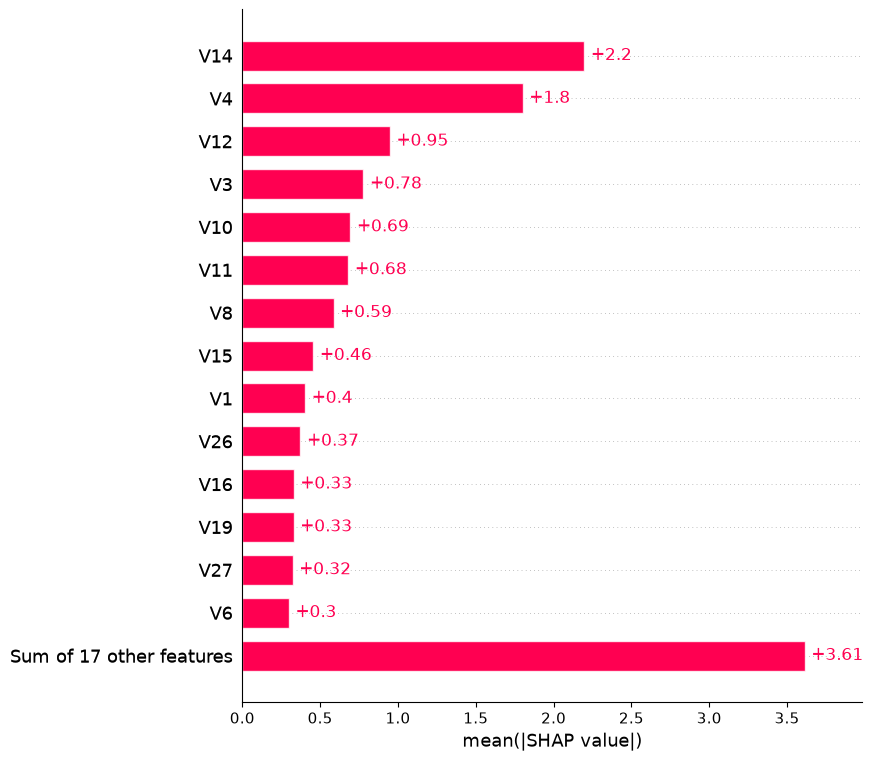

In [76]:
shap.plots.bar(
    shap_values,
    max_display=15
)

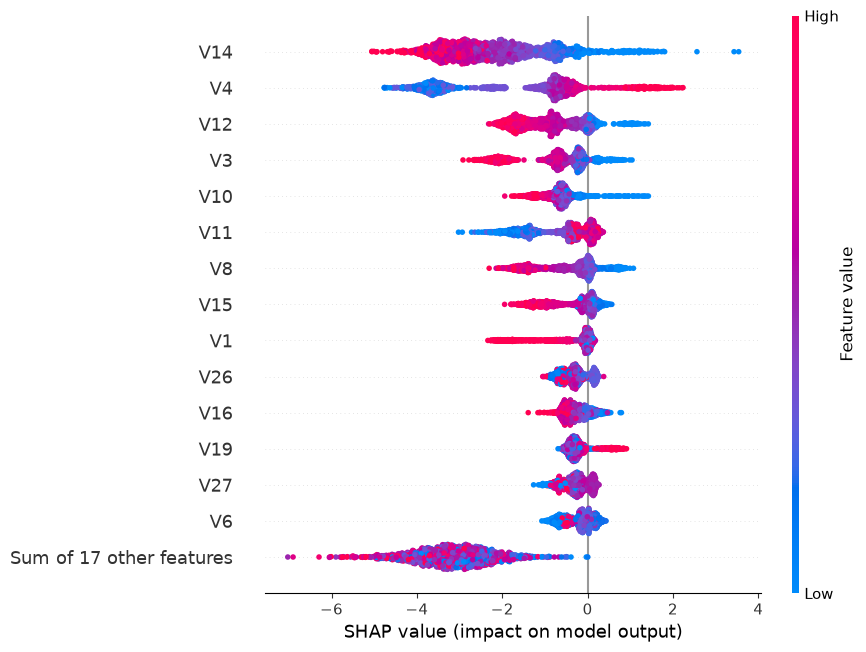

In [77]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

In [78]:
transaction_number = 0

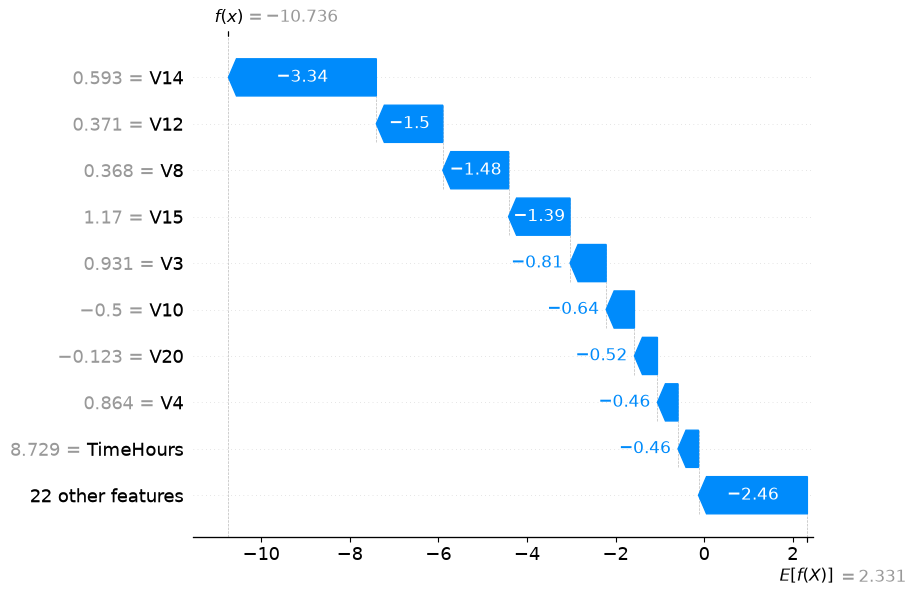

In [79]:
shap.plots.waterfall(
    shap_values[
        transaction_number
    ]
)

In [80]:
fraud_indices = y_val[
    y_val == 1
].index

fraud_sample = (
    X_val_fe.loc[
        X_val_fe.index.intersection(
            fraud_indices
        )
    ]
)

In [81]:
fraud_example = (
    fraud_sample.iloc[
        [0]
    ]
)

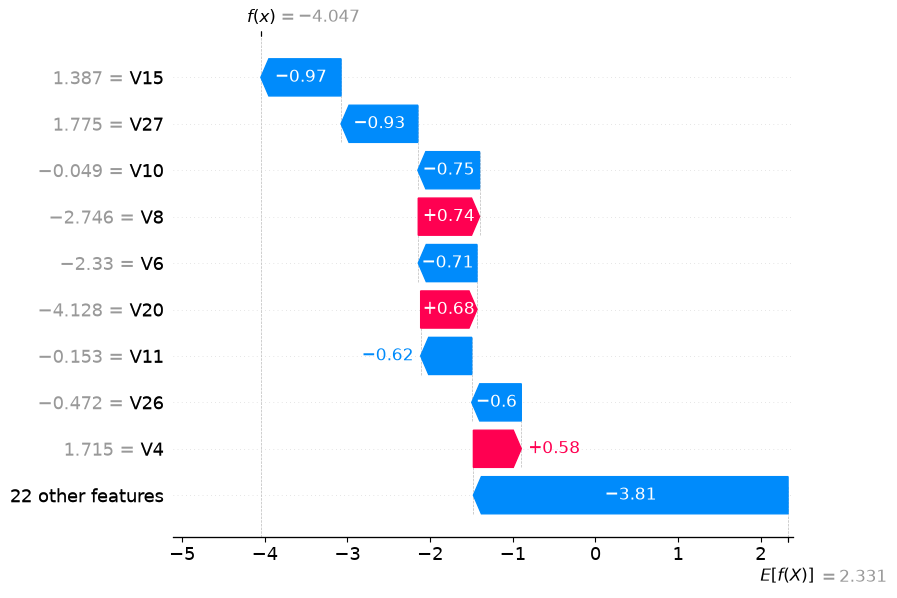

In [82]:
fraud_explainer = shap.Explainer(
    champion_model
)

fraud_shap = fraud_explainer(
    fraud_example
)

shap.plots.waterfall(
    fraud_shap[0]
)

## Model Explainability

SHAP was used to analyze the features influencing the champion model.

Several anonymized PCA components show strong influence on fraud
predictions. However, because V1-V28 represent transformed and
anonymized variables, their original business meaning is unknown.

Therefore, SHAP results are interpreted as model-level feature
influence rather than direct customer or transaction behavior.

In [83]:
import joblib
from pathlib import Path

artifact = {

    "model":
        champion_model,

    "model_name":
        champion_name,

    "threshold":
        float(
            champion_threshold
        ),

    "raw_columns":
        list(X_train.columns),

    "feature_columns":
        list(
            X_train_fe.columns
        ),

    "version":
        "1.0.0",

    "false_negative_cost":
        FALSE_NEGATIVE_COST,

    "false_positive_cost":
        FALSE_POSITIVE_COST,
}

In [84]:
MODEL_PATH = Path(
    "../artifacts/fraud_model.joblib"
)

joblib.dump(
    artifact,
    MODEL_PATH
)

['..\\artifacts\\fraud_model.joblib']

In [85]:
reference_sample = (
    X_train_fe
    .sample(
        n=min(
            50_000,
            len(X_train_fe)
        ),
        random_state=42
    )
)


In [86]:
reference_sample.to_csv(
    "../artifacts/reference_sample.csv",
    index=False
)

In [93]:
from pathlib import Path
import mlflow

PROJECT_ROOT = Path.cwd().parent

MLFLOW_DB = PROJECT_ROOT / "mlflow.db"

tracking_uri = (
    f"sqlite:///{MLFLOW_DB.resolve().as_posix()}"
)

mlflow.set_tracking_uri(
    tracking_uri
)

print("Project root:", PROJECT_ROOT.resolve())
print("MLflow DB:", MLFLOW_DB.resolve())
print("Tracking URI:", mlflow.get_tracking_uri())

Project root: C:\Birmingham\financial-fraud-detection-ml
MLflow DB: C:\Birmingham\financial-fraud-detection-ml\mlflow.db
Tracking URI: sqlite:///C:/Birmingham/financial-fraud-detection-ml/mlflow.db


In [94]:
experiment = mlflow.set_experiment(
    "credit-card-fraud"
)

print(
    "Experiment name:",
    experiment.name
)

print(
    "Experiment ID:",
    experiment.experiment_id
)

2026/09/24 15:47:27 INFO mlflow.tracking.fluent: Experiment with name 'credit-card-fraud' does not exist. Creating a new experiment.


Experiment name: credit-card-fraud
Experiment ID: 1


In [95]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

experiments = (
    client.search_experiments()
)

for exp in experiments:
    print(
        exp.experiment_id,
        exp.name
    )

1 credit-card-fraud
0 Default


In [96]:
with mlflow.start_run(
    run_name="xgboost_champion"
) as run:

    mlflow.log_param(
        "model",
        champion_name
    )

    mlflow.log_param(
        "threshold",
        champion_threshold
    )

    mlflow.log_param(
        "false_negative_cost",
        FALSE_NEGATIVE_COST
    )

    mlflow.log_param(
        "false_positive_cost",
        FALSE_POSITIVE_COST
    )

    mlflow.log_metric(
        "test_average_precision",
        final_test_results[
            "average_precision"
        ]
    )

    mlflow.log_metric(
        "test_pr_auc",
        final_test_results[
            "pr_auc"
        ]
    )

    mlflow.log_metric(
        "test_precision",
        final_test_results[
            "precision"
        ]
    )

    mlflow.log_metric(
        "test_recall",
        final_test_results[
            "recall"
        ]
    )

    mlflow.log_metric(
        "test_f1",
        final_test_results[
            "f1"
        ]
    )

    mlflow.log_metric(
        "false_positive",
        final_test_results[
            "fp"
        ]
    )

    mlflow.log_metric(
        "false_negative",
        final_test_results[
            "fn"
        ]
    )

    mlflow.log_metric(
        "business_cost",
        final_business_cost
    )

    print(
        "Run ID:",
        run.info.run_id
    )

Run ID: de53d68809ba45b79c169c7aa323a399


In [97]:
runs = mlflow.search_runs(
    experiment_names=[
        "credit-card-fraud"
    ]
)

runs[
    [
        "run_id",
        "tags.mlflow.runName",
        "params.model",
        "params.threshold",
        "metrics.test_precision",
        "metrics.test_recall",
        "metrics.business_cost"
    ]
]

,run_id,tags.mlflow.runName,params.model,params.threshold,metrics.test_precision,metrics.test_recall,metrics.business_cost
0,de53d68809ba45b79c169c7aa323a399,xgboost_champion,XGBoost,0.324,0.754902,0.810526,1850000.0


In [98]:
sample_request = (
    X_test.iloc[0]
    .to_dict()
)

sample_request

{'Time': 61290.0,
 'V1': 1.2288211502379,
 'V2': -0.0634077165201056,
 'V3': 0.274145142235826,
 'V4': 0.647465021810117,
 'V5': -0.0481345611508765,
 'V6': 0.372073028593297,
 'V7': -0.22423058741343,
 'V8': 0.0799390492455152,
 'V9': 0.640758817066441,
 'V10': -0.273053702248503,
 'V11': -1.25272793883718,
 'V12': 0.465078770741453,
 'V13': 0.400502115321077,
 'V14': -0.292841860600363,
 'V15': -0.10177401599731,
 'V16': -0.399835897844616,
 'V17': 0.0343356567914817,
 'V18': -0.783550254934187,
 'V19': 0.141344900433949,
 'V20': -0.0965659023514416,
 'V21': -0.129554448055005,
 'V22': -0.0837793282428063,
 'V23': -0.151661473916324,
 'V24': -0.700371597289218,
 'V25': 0.598550164523483,
 'V26': 0.491409070563651,
 'V27': 0.0029892597250263,
 'V28': 0.0017822861144491,
 'Amount': 11.5}